## Baseline HAR Model

In [80]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

DATA_PATH = os.path.join('..', 'data', 'panel_data_model_ready.parquet')

df = pd.read_parquet(DATA_PATH)
print(f'Data Shape: {df.shape}')
display(df.head())

har_features = ['rv_lag_1', 'rv_rolling_5', 'rv_rolling_22']
Y = df['Y_reg']

har_extended_features = har_features + ['vix_lag_1', 'bpv_lag_1', 'rq_lag_1']
X_har = df[har_features]

X_advanced = df.drop(columns=['rv', 'bpv', 'good', 'bad', 'rq', 'vix', 'Y_reg'])

df_har = df.copy()
df_har = df.dropna(subset=['rv_lag_1','rv_rolling_5','rv_rolling_22','Y_reg']).copy()
df_har = df_har.sort_index(level=['Stock', 'Date'])

print(f'Target (Y) shape: {Y.shape}')
print(f'HAR Features (X_har) shape: {X_har.shape}')
print(f'Advanced Features (X_advanced) shape: {X_advanced.shape}')
display(X_har.head())
display(X_har.tail())

Data Shape: (153515, 17)


rv       bpv      good       bad         rq    vix  \
Date       Stock                                                             
2003-01-03 AAPL   6.574494  5.893317  3.638035  2.936459  62.054316  24.68   
           AMGN   3.225009  3.043199  1.961131  1.263879  31.538602  24.68   
           AMZN   5.290480  4.212468  3.812314  1.478167  61.555140  24.68   
           AXP    3.394580  3.409980  1.725383  1.669197  13.330858  24.68   
           BA     3.064001  3.755029  1.403990  1.660010  13.424943  24.68   

                     Y_reg  rv_lag_1  rv_rolling_5  rv_rolling_22  bpv_lag_1  \
Date       Stock                                                               
2003-01-03 AAPL   5.992264  6.493909      6.493909       6.493909   3.771960   
           AMGN   2.460476  5.177506      5.177506       5.177506   3.635898   
           AMZN   5.818162  9.886836      9.886836       9.886836   8.018926   
           AXP    4.693210  4.448244      4.448244       4.448244   4.122573   
           BA     2.934207  7.469396      7.469396       7.469396   7.016747   

                  good_lag_1  bad_lag_1    rq_lag_1  vix_lag_1  \
Date       Stock                                                 
2003-01-03 AAPL     5.102315   1.391595  152.729402      25.39   
           AMGN     3.362921   1.814585   46.168213      25.39   
           AMZN     6.074276   3.812559  200.751309      25.39   
           AXP      3.337253   1.110991  114.695371      25.39   
           BA       5.107386   2.362010  150.112379      25.39   

                  bad_good_ratio_lag_1  jump_ratio_lag_1  
Date       Stock                                          
2003-01-03 AAPL               0.272738          0.419154  
           AMGN               0.539586          0.297751  
           AMZN               0.627656          0.188929  
           AXP                0.332906          0.073213  
           BA                 0.462469          0.060600

Target (Y) shape: (153515,)
HAR Features (X_har) shape: (153515, 3)
Advanced Features (X_advanced) shape: (153515, 10)


rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2003-01-03 AAPL   6.493909      6.493909       6.493909
           AMGN   5.177506      5.177506       5.177506
           AMZN   9.886836      9.886836       9.886836
           AXP    4.448244      4.448244       4.448244
           BA     7.469396      7.469396       7.469396

rv_lag_1  rv_rolling_5  rv_rolling_22
Date       Stock                                       
2024-03-27 TRV    0.662026      0.509677       0.658727
           UNH    0.738759      0.577990       1.216626
           V      1.870995      0.907149       0.653616
           VZ     0.304812      0.675192       1.060689
           WMT    0.523779      0.504518       0.655106

## Rolling window

Initialized TimeSeriesSplit with 5 splits.


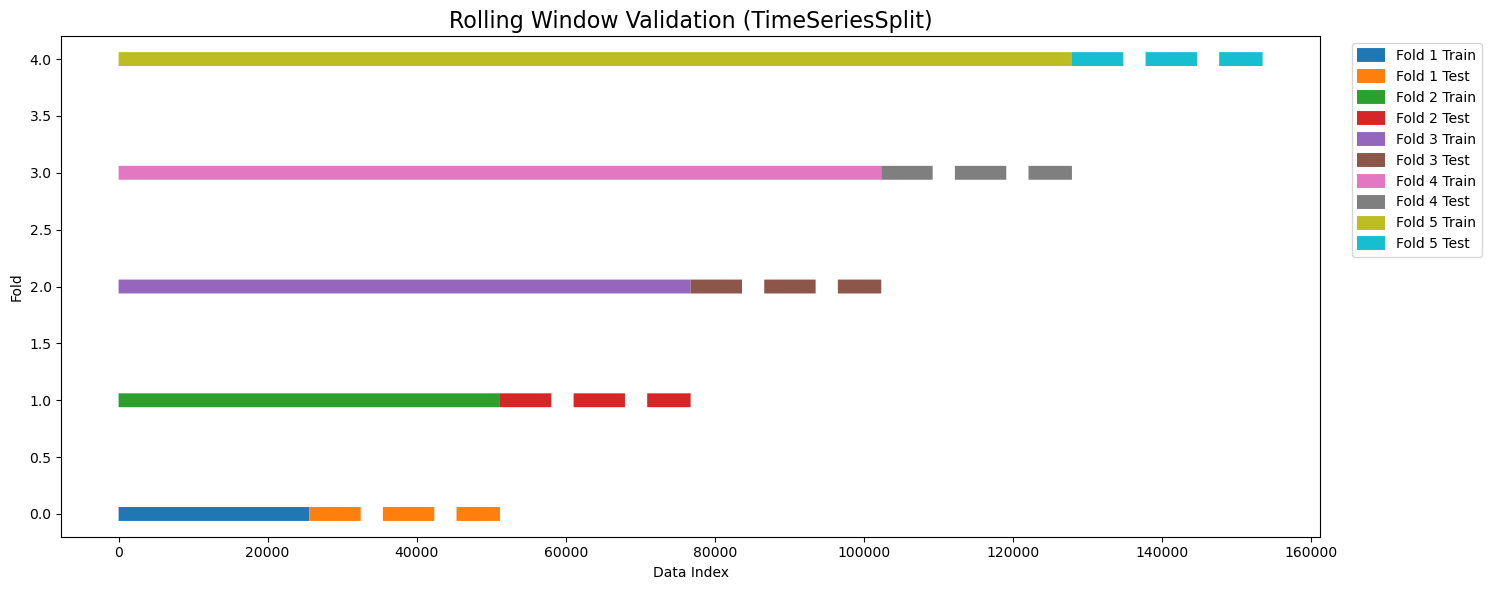

In [81]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f'Initialized TimeSeriesSplit with {N_SPLITS} splits.')

fig, ax = plt.subplots(figsize=(15, 6))
for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    ax.plot(train_index, [i] * len(train_index), label=f'Fold {i+1} Train', lw=10, solid_capstyle='butt')
    ax.plot(test_index, [i] * len(test_index), label=f'Fold {i+1} Test', lw=10, ls='--', solid_capstyle='butt')

ax.set_title('Rolling Window Validation (TimeSeriesSplit)', fontsize=16)
ax.set_xlabel('Data Index')
ax.set_ylabel('Fold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Train HAR model

In [82]:
# Method 1: using 80%-20% train-test split
split_date = '2020-01-01'
train = df_har.loc[df_har.index.get_level_values('Date') < split_date]
test  = df_har.loc[df_har.index.get_level_values('Date') >= split_date]

X_train = train[['rv_lag_1','rv_rolling_5','rv_rolling_22']]
y_train = train['Y_reg']
X_test  = test[['rv_lag_1','rv_rolling_5','rv_rolling_22']]
y_test  = test['Y_reg']

har_model = LinearRegression()
har_model.fit(X_train, y_train)

y_pred = har_model.predict(X_test)
test['har_pred'] = y_pred

mse = mean_squared_error(y_test, y_pred)
print(f"HAR Baseline Test MSE: {mse:.6f}")

df.loc[test.index, 'har_pred'] = y_pred
df['residual'] = df['Y_reg'] - df['har_pred']

mse_per_stock = (
    test.groupby('Stock')
        .apply(lambda g: mean_squared_error(g['Y_reg'], g['har_pred']))
        .sort_values()
)

print(f"average per-stock MSE: {mse_per_stock.mean():.6f}")
print(f"median per-stock MSE: {mse_per_stock.median():.6f}")

HAR Baseline Test MSE: 21.783349
average per-stock MSE: 21.783349
median per-stock MSE: 13.239796


C:\Users\lenovo\AppData\Local\Temp\ipykernel_34248\3355706418.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['har_pred'] = y_pred


In [83]:
# Method 2: rolling window folds split
har_mse_scores = []
har_models = []

print('Training & Evaluation for HAR...')

for i, (train_index, test_index) in enumerate(tscv.split(X_har)):
    print(f'--- Fold {i+1}/{N_SPLITS} ---')
    
    X_train, X_test = X_har.iloc[train_index], X_har.iloc[test_index]
    y_train, y_test = Y.iloc[train_index], Y.iloc[test_index]
    
    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    har_model = LinearRegression()
    har_model.fit(X_train, y_train)
    
    y_pred = har_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    har_mse_scores.append(mse)
    har_models.append(har_model)
    
    print(f"  Fold {i+1} MSE: {mse:.6f}")
    
average_har_mse = np.mean(har_mse_scores)
print(f"Average HAR Model MSE across all {N_SPLITS} folds: {average_har_mse:.6f}")

Training & Evaluation for HAR...
--- Fold 1/5 ---
  Train size: 25590, Test size: 25585
  Fold 1 MSE: 68.339775
--- Fold 2/5 ---
  Train size: 51175, Test size: 25585
  Fold 2 MSE: 2.732427
--- Fold 3/5 ---
  Train size: 76760, Test size: 25585
  Fold 3 MSE: 7.711325
--- Fold 4/5 ---
  Train size: 102345, Test size: 25585
  Fold 4 MSE: 23.424113
--- Fold 5/5 ---
  Train size: 127930, Test size: 25585
  Fold 5 MSE: 5.622599
Average HAR Model MSE across all 5 folds: 21.566048


## Isolation Forest modelling

In [43]:
from sklearn.ensemble import IsolationForest

df_full_har = df.dropna(subset=har_features + [target_col]).copy()
X_full = df_full_har[har_features].to_numpy()
df_full_har['har_pred'] = har_model.predict(X_full)
df_full_har['residual'] = df_full_har['Y_reg'] - df_full_har['har_pred']

# Isolation forest
def fit_predict_isolation_forest_per_stock(g):
    dates_g = g.index.get_level_values('Date')
    train_mask_g = (dates_g >= pd.Timestamp('2003-01-01')) & (dates_g <= pd.Timestamp('2019-12-31'))
    g_train = g.loc[train_mask_g]

    # label "normal" if no data
    if g_train.empty:
        g['resid_z'] = 0.0
        g['if_label'] = 1
        return g

    # make z-score
    eps = 1e-8
    mu = g_train['residual'].mean()
    sd = g_train['residual'].std(ddof=0)
    g['resid_z'] = (g['residual'] - mu) / (sd + eps)

    # train if
    iso = IsolationForest(
        n_estimators=200,
        contamination='auto', 
        random_state=42,
        n_jobs=-1
    )
    iso.fit(g.loc[train_mask_g, ['resid_z']].to_numpy())

    g['if_label'] = iso.predict(g[['resid_z']].to_numpy())
    return g

df_if = df_full_har.groupby(level='Stock', group_keys=False).apply(fit_predict_isolation_forest_per_stock)

# make abnormal label
df_if['is_abnormal'] = (df_if['if_label'] == -1).astype(int)
df_if['Y_class'] = df_if['is_abnormal']  

# check the %
dates_all = df_if.index.get_level_values('Date')
train_mask_all = (dates_all >= pd.Timestamp('2003-01-01')) & (dates_all <= pd.Timestamp('2019-12-31'))
test_mask_all  = (dates_all >= pd.Timestamp('2020-01-01')) & (dates_all <= pd.Timestamp('2024-12-31'))

train_abn_rate = df_if.loc[train_mask_all, 'is_abnormal'].mean()
test_abn_rate  = df_if.loc[test_mask_all,  'is_abnormal'].mean()
print(f"[IF] abnormal% | train: {train_abn_rate:.4%}  test: {test_abn_rate:.4%}")

print("\n example for stock 0 ）：")
sample_stock = df_if.index.get_level_values('Stock')[0]
print(df_if.xs(sample_stock, level='Stock').tail()[['Y_reg','har_pred','residual','resid_z','is_abnormal']].head())


[IF] abnormal% | train: 10.8053%  test: 17.7330%

 example for stock 0 ）：
               Y_reg  har_pred  residual   resid_z  is_abnormal
Date                                                           
2024-03-21  2.876235  2.242212  0.634023  0.305608            0
2024-03-22  5.865156  1.772104  4.093051  1.850305            1
2024-03-25  2.785550  2.120349  0.665201  0.319531            0
2024-03-26  1.776870  2.192069 -0.415199 -0.162943            0
2024-03-27  1.049129  1.484792 -0.435663 -0.172081            0


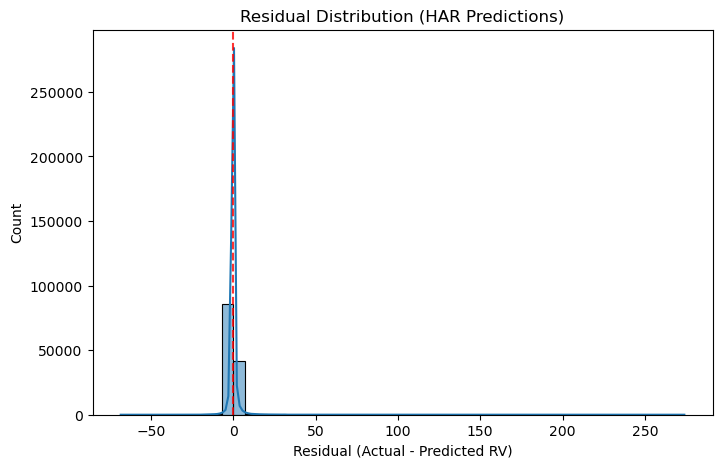

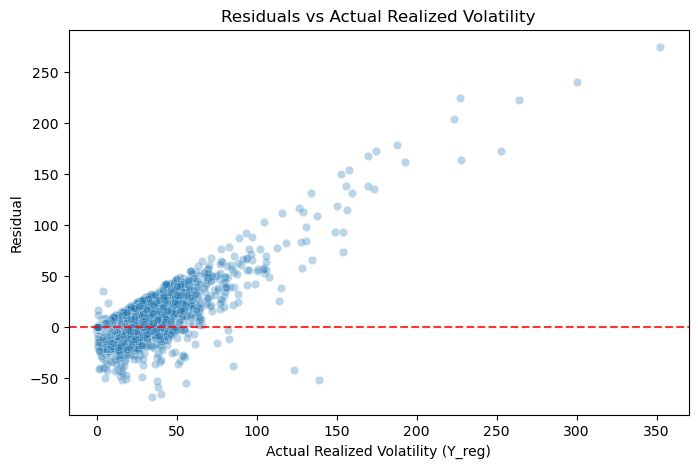

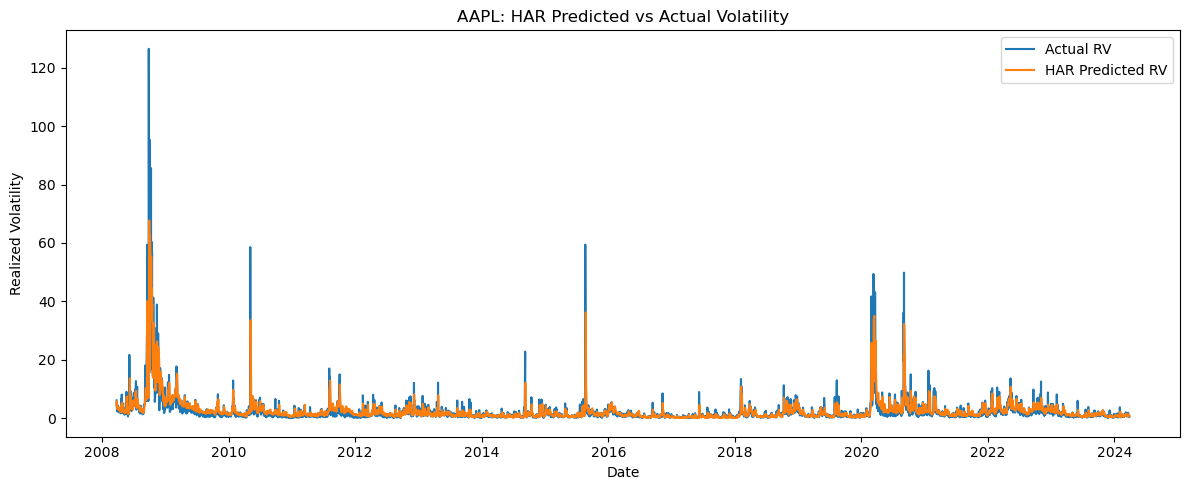

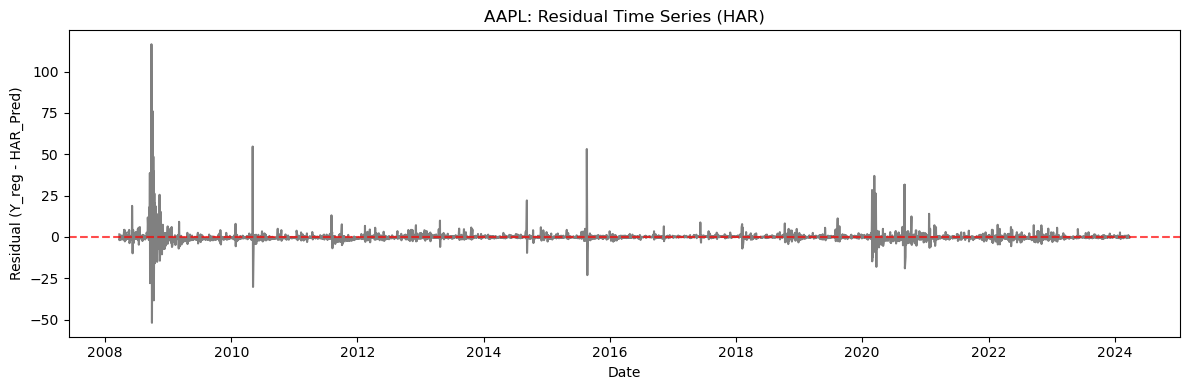

In [44]:
# HAR residual visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))
sns.histplot(df_full_har['residual'], bins=50, kde=True)
plt.title('Residual Distribution (HAR Predictions)')
plt.xlabel('Residual (Actual - Predicted RV)')
plt.ylabel('Count')
plt.axvline(0, color='red', linestyle='--', alpha=0.8)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Y_reg', y='residual', data=df_full_har, alpha=0.3)
plt.title('Residuals vs Actual Realized Volatility')
plt.xlabel('Actual Realized Volatility (Y_reg)')
plt.ylabel('Residual')
plt.axhline(0, color='red', linestyle='--', alpha=0.8)
plt.show()

sample_stock = 'AAPL'  
sample = df_full_har.xs(sample_stock, level='Stock')

plt.figure(figsize=(12,5))
plt.plot(sample.index, sample['Y_reg'], label='Actual RV', linewidth=1.5)
plt.plot(sample.index, sample['har_pred'], label='HAR Predicted RV', linewidth=1.5)
plt.title(f'{sample_stock}: HAR Predicted vs Actual Volatility')
plt.xlabel('Date')
plt.ylabel('Realized Volatility')
plt.legend()
plt.tight_layout()
plt.show()

# residual time series
plt.figure(figsize=(12,4))
plt.plot(sample.index, sample['residual'], label='Residuals', color='gray')
plt.axhline(0, color='red', linestyle='--', alpha=0.7)
plt.title(f'{sample_stock}: Residual Time Series (HAR)')
plt.xlabel('Date')
plt.ylabel('Residual (Y_reg - HAR_Pred)')
plt.tight_layout()
plt.show()
